## Exercícios Práticos para os Métodos de Integração Numérica

In [92]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Integração Numérica

Tome como exercício o exemplo visto na apostila para os métodos de integração numérica:

$$
\int_{0}^{1.2} e^x \cos(x)\,dx
$$

sabendo que o valor correto da integral é:

$$
1.64877\ldots
$$

Resolva os seguintes itens, comparando as soluções obtidas com a solução real.


In [93]:
def f(x):
    return np.exp(x) * np.cos(x)

#### a)

Aproxime o valor da integral usando a Regra do Trapézio Generalizada, com:

- $N = 6$
- $N = 24$


In [94]:
def trapezio_generalizada(a, b, N, f):
    n = N + 1

    h = (b - a) / N
    xi = np.linspace(a, b, n)
    yi = f(xi)

    soma = 0
    for k in range(n):
        if k == 0 or k == N:
            soma = soma + yi[k]
        else:
            soma = soma + 2 * yi[k]

    I_trap = (h / 2) * soma

    return I_trap

print(f"Integral (N = 6) = {trapezio_generalizada(0, 1.2, 6, f)}")
print(f"Integral (N = 24) = {trapezio_generalizada(0, 1.2, 24, f)}")

Integral (N = 6) = 1.639151078777383
Integral (N = 24) = 1.6481721078045821


#### b)

Utilize a Regra de $1/3$ de Simpson Generalizada, utilizando:

- $N = 3$
- $N = 12$

In [95]:
def simpson_1_3(a, b, N, f):
    n = 2 * N + 1

    h = (b - a) / (2 * N)
    xi = np.linspace(a, b, n)
    yi = f(xi)

    soma = 0
    for k in range(n):
        if k == 0 or k == 2 * N:
            soma = soma + yi[k]
        elif k % 2 == 1:
            soma = soma + 4 * yi[k]
        else:
            soma = soma + 2 * yi[k]

    I_trap = (h / 3) * soma
    return I_trap

print(f"Integral (N = 6) = {simpson_1_3(0, 1.2, 3, f)}")
print(f"Integral (N = 24) = {simpson_1_3(0, 1.2, 12, f)}")

Integral (N = 6) = 1.6487153194289974
Integral (N = 24) = 1.6487741982313593


### c)

Utilize a Regra de $3/8$ de Simpson Generalizada, utilizando:

- $N = 2$
- $N = 8$

In [96]:
def simpson_3_8(a, b, N, f):
    n = 3 * N + 1

    h = (b - a) / (3 * N)
    xi = np.linspace(a, b, n)
    yi = f(xi)

    soma = 0
    for k in range(n):
        if k == 0 or k == 3 * N:
            soma = soma + yi[k]
        elif k % 3 == 0:
            soma = soma + 2 * yi[k]
        else:
            soma = soma + 3 * yi[k]

    I_trap = ((3 * h) / 8) * soma
    return I_trap

print(f"Integral (N = 6) = {simpson_3_8(0, 1.2, 3, f)}")
print(f"Integral (N = 24) = {simpson_3_8(0, 1.2, 12, f)}")

Integral (N = 6) = 1.6487481810342197
Integral (N = 24) = 1.6487743255238663


## 2. Método dos Mínimos Quadrados

Aproxime a função

$$
f(x) = \sin(x)
$$

por um polinômio de grau $2$, $3$ e $5$, de forma numérica, pelo método dos mínimos quadrados.


In [97]:
def f(x):
    return np.sin(x)

In [98]:
def minimos_quadrados(xi, yi, m):

    n = len(xi)
    mn = m + 1

    u = np.zeros((n, mn))

    for i in range(mn):
        u[:, i] = xi[:] ** i

    G = np.zeros((mn, mn))
    b = np.zeros(mn)

    for i in range(mn):
        b[i] = np.sum(u[:, i] * yi)
        for j in range(mn):
            G[i, j] = np.sum(u[:, i] * u[:, j])

    a = np.linalg.inv(G) @ b

    # pontos para desenhar curva
    N = 200
    x = np.linspace(xi[0], xi[-1], N)

    P = np.zeros((N, mn))

    for i in range(mn):
        P[:, i] = x[:] ** i

    y_aprox = P @ a

    return x, y_aprox, a

### a)

Obtenha de forma numérica a expressão para estes polinômios:

$$
a_0 + a_1x + a_2x^2 + \ldots + a_nx^n
$$


In [99]:
n = 30

xi = np.linspace(0, 2 * np.pi, n)
yi = f(xi)

x1, y1, coef1 = minimos_quadrados(xi, yi, 2)
x3, y3, coef3 = minimos_quadrados(xi, yi, 3)
x5, y5, coef5 = minimos_quadrados(xi, yi, 5)

print(f"P2(x) = {coef1[0]:.2f} + {coef1[1]:.2f}x + {coef1[2]:.2f}x²")
print(f"P3(x) = {coef3[0]:.2f} + {coef3[1]:.2f}x + {coef3[2]:.2f}x² + {coef3[3]:.2f}x³")
print(f"P5(x) = {coef5[0]:.2f} + {coef5[1]:.2f}x + {coef5[2]:.2f}x² + {coef5[3]:.2f}x³ + {coef5[4]:.2f}x⁴ + {coef5[5]:.2f}x⁵")

P2(x) = 0.86 + -0.27x + -0.00x²
P3(x) = -0.14 + 1.82x + -0.85x² + 0.09x³
P5(x) = 0.01 + 0.89x + 0.26x² + -0.39x³ + 0.09x⁴ + -0.01x⁵


### b)

Plote a curva da função $f(x)$ junto com as curvas dos polinômios obtidos, para fins de comparação, em um único gráfico.

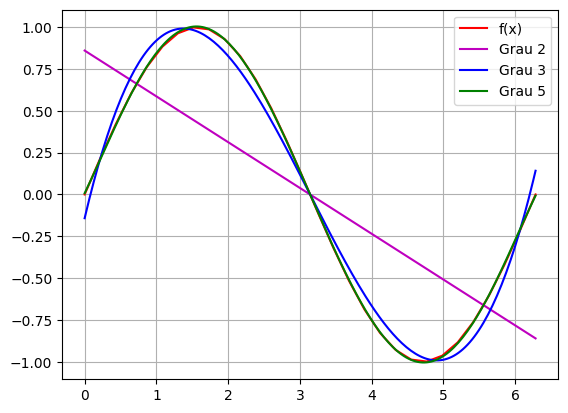

In [100]:
plt.plot(xi, yi, 'r', label='f(x)')
plt.plot(x1, y1, 'm', label='Grau 2')
plt.plot(x3, y3, 'b', label='Grau 3')
plt.plot(x5, y5, 'g', label='Grau 5')
plt.legend()
plt.grid(True)
plt.show()